# fase 8: interpretabilidade

so carrega o modelo enxuto salvo em models/model.pkl, nao treina nada. separado do 04_model.ipynb porque a maquina tem 8gb de ram e segurar o rf de 200 arvores + o de 100 + shap + permutation ao mesmo tempo estourava memoria e derrubava o kernel.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance

model = joblib.load("../models/model.pkl")
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]
feature_names = preprocessor.get_feature_names_out()


def clean_feature_name(name):
    return name.split("__", 1)[-1]  # tira o prefixo do ColumnTransformer (numeric__, rhum__, station__), so pra exibicao

## split temporal (so pra ter X_test/y_test -- nao precisa do treino aqui)

In [2]:
df = pd.read_csv("../data/processed/hourly_features.csv")

hour_utc = pd.to_datetime(df["hour_utc"], utc=True)
cutoff = pd.Timestamp("2026-06-01", tz="UTC")
test_mask = hour_utc >= cutoff

FEATURE_COLUMNS = [
    "hour_of_day", "day_of_week", "is_weekend",
    "temp", "prcp", "rhum", "wspd",
    "capacity", "lat", "lon",
    "station_id",
]
TARGET_COLUMN = "is_empty"

X_test = df.loc[test_mask, FEATURE_COLUMNS]
y_test = df.loc[test_mask, TARGET_COLUMN]
X_test.shape

(81566, 11)

## 1. feature_importances_

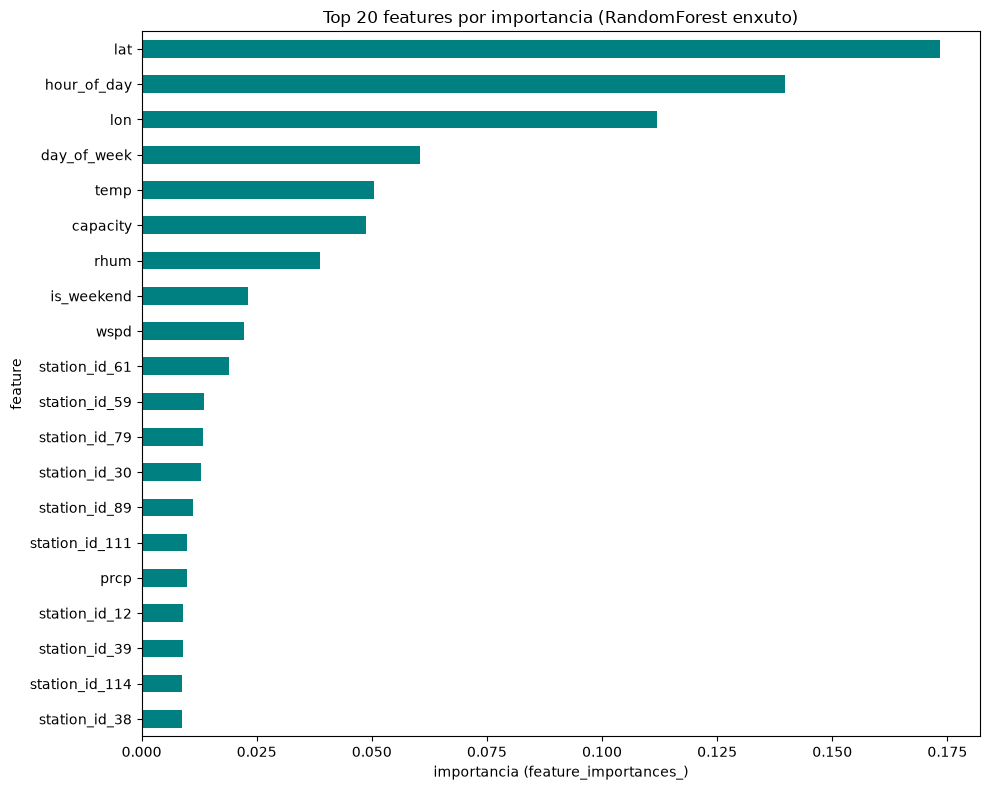

In [3]:
importances = pd.Series(classifier.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)
top20_display = top20.copy()
top20_display.index = [clean_feature_name(n) for n in top20.index]

fig, ax = plt.subplots(figsize=(10, 8))
top20_display.sort_values().plot.barh(ax=ax, color="teal")
ax.set_title("Top 20 features por importancia (RandomForest enxuto)")
ax.set_xlabel("importancia (feature_importances_)")
ax.set_ylabel("feature")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150)
plt.show()

## 2. shap (amostra de 2000 linhas do teste)

shap em 81 mil linhas com 100 arvores demora demais -- amostra de 2000. mesma amostra usada depois no permutation_importance.

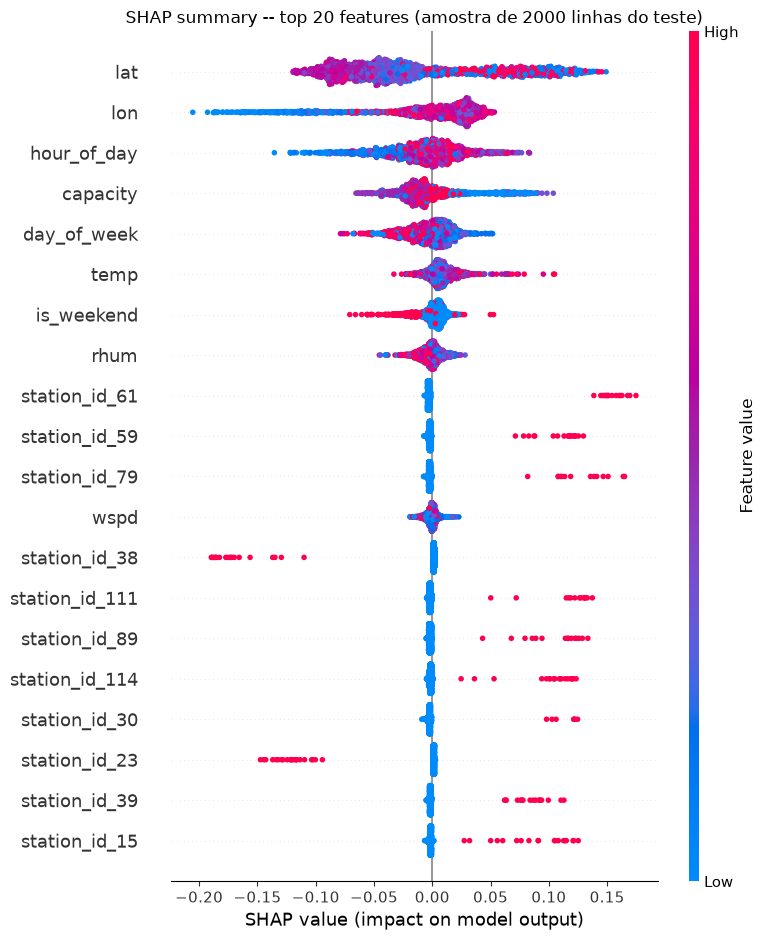

In [4]:
X_test_sample = X_test.sample(n=2000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]
X_test_sample_transformed = preprocessor.transform(X_test_sample).toarray().astype(np.float64)  # TreeExplainer precisa de array denso, nao esparso
feature_names_clean = [clean_feature_name(n) for n in feature_names]

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_sample_transformed)
shap_values_empty = shap_values[:, :, 1]  # classe 1 = estacao vazia, e a que interessa pro summary plot

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_empty, X_test_sample_transformed, feature_names=feature_names_clean, show=False, max_display=20)
plt.title("SHAP summary -- top 20 features (amostra de 2000 linhas do teste)")
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150)
plt.show()

## 3. importancia por categoria (gini)

In [5]:
station_features = [n for n in feature_names if n.startswith("station__")] + ["numeric__lat", "numeric__lon", "numeric__capacity"]
tempo_features = ["numeric__hour_of_day", "numeric__day_of_week", "numeric__is_weekend"]
clima_features = ["numeric__temp", "numeric__prcp", "rhum__rhum", "numeric__wspd"]

category_importance = pd.Series({
    "station": importances[station_features].sum(),
    "tempo": importances[tempo_features].sum(),
    "clima": importances[clima_features].sum(),
})
category_importance_pct = (category_importance / category_importance.sum() * 100).round(1)
category_importance_pct

station    65.5
tempo      22.3
clima      12.1
dtype: float64

## 4. validacao: permutation_importance (corrige o viés do gini)

feature_importances_ e gini importance: favorece variaveis continuas com muitos valores possiveis (temp, rhum, lat, lon), porque a arvore tem mais chances de testar corte nelas -- mesmo quando o ganho real e ruido. isso pode estar inflando clima, que na eda (fase 4) nao mostrou efeito visivel.

permutation_importance mede a queda real de f1 quando a coluna e embaralhada -- mede contribuicao de fato pra previsao, nao so oportunidade de split. mais caro de calcular, por isso roda so na mesma amostra de 2000 linhas do shap.

In [6]:
perm_result = permutation_importance(
    classifier, X_test_sample_transformed, y_test_sample,
    n_repeats=5, scoring="f1", random_state=42, n_jobs=-1,
)
perm_importances = pd.Series(perm_result.importances_mean, index=feature_names)
perm_std = pd.Series(perm_result.importances_std, index=feature_names)

top15_perm = perm_importances.sort_values(ascending=False).head(15).round(4)
top15_perm.index = [clean_feature_name(n) for n in top15_perm.index]
top15_perm

lat               0.1202
hour_of_day       0.0963
lon               0.0716
day_of_week       0.0454
capacity          0.0228
is_weekend        0.0224
rhum              0.0116
station_id_65     0.0080
station_id_73     0.0045
station_id_90     0.0034
station_id_15     0.0029
station_id_18     0.0021
station_id_76     0.0021
station_id_108    0.0020
station_id_27     0.0020
dtype: float64

In [7]:
# permutation pode dar negativo (embaralhar uma coluna irrelevante as vezes "ajuda" por acaso); trata como 0 pro percentual
perm_category = pd.Series({
    "station": perm_importances[station_features].sum(),
    "tempo": perm_importances[tempo_features].sum(),
    "clima": perm_importances[clima_features].sum(),
}).clip(lower=0)
perm_category_pct = (perm_category / perm_category.sum() * 100).round(1)

category_comparison = pd.DataFrame({
    "gini_pct": category_importance_pct,
    "permutation_pct": perm_category_pct,
})
category_comparison

,gini_pct,permutation_pct
station,65.5,61.1
tempo,22.3,35.9
clima,12.1,3.1


**clima encolhe bastante: 12.1% (gini) -> 3.1% (permutation), quase 4x menor.** dentro de clima, so rhum tem sinal que passa do ruido (media 0.0116, desvio-padrao 0.0033 nos 5 repeats -- media bem acima do proprio desvio). temp, wspd e prcp ficam dentro do proprio desvio-padrao (indistinguivel de ruido), e prcp fica ate levemente negativo (-0.00002 +- 0.0042). bate com o achado da fase 4: chuva nao tinha efeito visivel nos dados -- o gini estava inflando clima por favorecer variaveis continuas com muitos valores unicos pra testar corte, nao porque elas ajudassem a prever de verdade.

station tambem cai um pouco (65.5% -> 61.1%) e tempo sobe bastante (22.3% -> 35.9%) -- o gini estava subestimando tempo em relacao ao bloco de 115 colunas de station. em unidade bruta (mesma escala do top 15 acima), hour_of_day sozinho (0.096) ja vale quase 7x a soma inteira de clima (0.014).

## achados (interpretabilidade)

**numeros principais sao de permutation_importance, nao gini** -- gini favorece variaveis continuas (temp, rhum, lat, lon) so por terem mais pontos de corte pra arvore testar, e isso inflava clima (ver secao 4). gini fica so como comparacao.

**station domina: 61.1% da importancia (gini dizia 65.5%). tempo vem em segundo com 35.9% (gini subestimava, dizia 22.3%). clima cai pra so 3.1% (gini inflava, dizia 12.1%).**

dentro de station, o mais forte continua sendo lat e lon, nao station_id individual -- o modelo aprende uma zona geografica continua, nao decora estacao por estacao. hour_of_day e o 2o lugar geral nos dois metodos, e sozinho (0.096 em unidade bruta) ja vale quase 7x a soma inteira de clima (0.014).

isso bate com os achados de negocio da fase 4: estacoes-problema concentram a emptiness (station domina), tem padrao de commute nos horarios (tempo importa de verdade, mais do que o gini sugeria), e chuva nao tinha efeito visivel nos dados (clima quase nao sobrevive a validacao -- so rhum tem sinal acima do ruido, prcp fica ate negativo).

o shap summary confirma a ordem de topo (lat, lon, hour_of_day, capacity, day_of_week) e mostra a direcao: lat baixo empurra a previsao pra "vazia", lat alto pro lado oposto -- uma faixa geografica especifica da cidade concentra o risco.

## o que isso significa na pratica

pra quem usa o app: localizacao e horario -- nao o clima -- sao os fatores que realmente explicam se uma estacao costuma ficar vazia. reforca a fase 4: vale mais investir em rebalanceamento direcionado por zona/horario de commute do que em qualquer ajuste baseado em previsao do tempo.